# Worksheet S1: Carga y preprocesamiento básico de imágenes

## Objetivos

En este cuaderno se introducen los pasos fundamentales de la fase de **carga y preprocesamiento de imágenes** en visión por computador. Los objetivos son:

- Cargar imágenes desde disco y visualizar su contenido.
- Entender la representación interna de una imagen como un array de `numpy`.
- Convertir entre distintos espacios de color (RGB, escala de grises).
- Redimensionar, recortar y aplicar transformaciones geométricas simples.
- Normalizar y ajustar el contraste mediante histogramas.
- Aplicar filtros básicos de suavizado y reducción de ruido.
- Extraer bordes sencillos.
- Construir una **función de preprocesamiento** reutilizable para futuros modelos.

## Configuración del entorno

Se asume que el cuaderno se ejecuta en un entorno con Python 3 y las librerías `numpy`, `matplotlib`, `scikit-image` y opcionalmente `opencv-python` instaladas. En caso de utilizar Google Colab, será suficiente con instalar las dependencias que falten mediante `pip`.

Se importan las librerías necesarias y se configuran algunas opciones básicas de visualización.

In [ ]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, transform, exposure, filters, util, morphology

# Opcional: OpenCV para ilustrar diferenciar entre BGR y RGB
try:
    import cv2
    OPENCV_AVAILABLE = True
except ImportError:
    OPENCV_AVAILABLE = False

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['image.cmap'] = 'gray'

## ¿Qué es una imagen?

Para un ordenador una imagen es una matriz de 2 dimensiones (anchura y altura). Cada imagen está compuesta por píxels que son cada uno de los puntos básicos que componen una imagen.

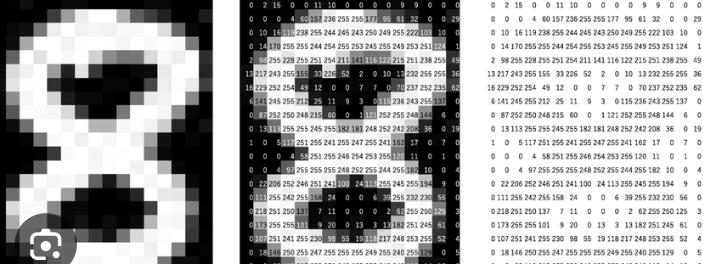

## Espacios de color

Cada uno de los píxeles, representa un valor de color. Generalmente trabajamos con tres tipos de `espacios de color`:

* **Monocromo**: cada pixel puede valer 0 (negro) o 255 (blanco).
* **Escala de grises**: en los que cada pixel contiene información del nivel de intensidad de luz. Cualquier valor entre 0 (negro) y 255 (blanco).
* **Color (RGB)**: cada pixel tiene 3 valores de intensidad independientes, cada uno relativo a un `canal` de color. R=Rojo, G=Verde y B=Azul. El módelo RGB es un modelo aditivo que mediante la combinación de estos tres componentes podemos obtener todos los colores.

## 1. Carga de imágenes

Se trabajará con imágenes almacenadas en disco. Para mantener el código organizado, se define una carpeta base para las imágenes y se especifica el nombre de un archivo de ejemplo. Es necesario **ajustar estas rutas** a la estructura concreta que se utilice (por ejemplo, una carpeta `img/` en el mismo directorio que el cuaderno).

In [ ]:
image_path = "img/santander.png"

print("Ruta de la imagen:", image_path)

Ruta de la imagen: /content/santander.png


### 1.1 Lectura y visualización

Se utiliza `skimage.io.imread` para cargar la imagen en memoria como un array de `numpy`. Posteriormente se visualiza con `matplotlib`. Si la imagen tiene tres canales, se asume que está en formato RGB (salvo cuando se cargue con OpenCV, que utiliza BGR por defecto).

Tipo de dato: uint8
Forma (alto, ancho, canales): (178, 283, 3)
Valor mínimo: 0
Valor máximo: 255


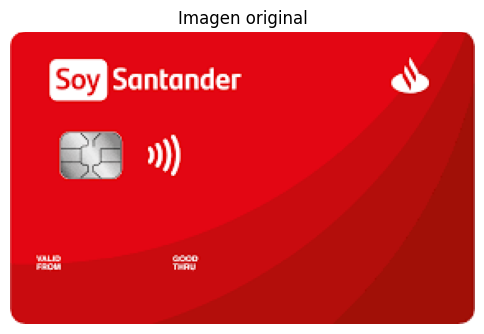

In [ ]:
img = io.imread(image_path)

print("Tipo de dato:", img.dtype)
print("Forma (alto, ancho, canales):", img.shape)
print("Valor mínimo:", img.min())
print("Valor máximo:", img.max())

plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")
plt.show()

En este caso, la imagen tiene 178 pixels de altura, 283 de anchura y 3 canales (RGB). Es importante destacar el sentido de cada coordenada (fíjate en los ejes de coordenadas de la imagen superior):

* Anchura: Va de izquierda a derecha.
* Altura: Va de arriba a abajo
* Espacio de color: si es RGB, va R en la coordenada 0, G en la 1 y B en la dos.

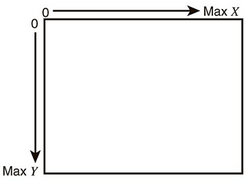

En la imagen anterior si queremos acceder a un pixel cerca del centro podemos hacerlo de la siguiente manera:

Otras alternativas para mostrar imágenes.

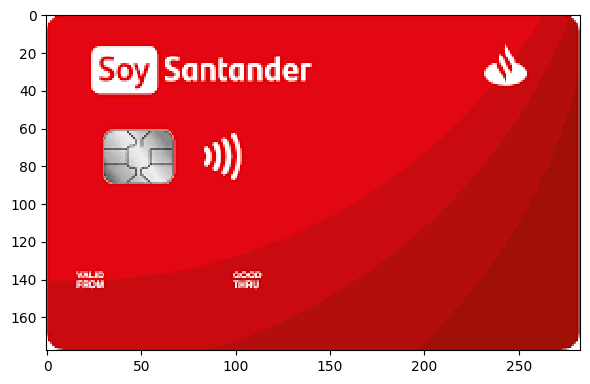

In [ ]:
io.imshow(img)
io.show()

In [ ]:
# Imprimir una porción pequeña del array (esquina superior izquierda, 3x3 píxeles)
print("Primeros 3x3 píxeles (RGB):")
print(img[:3, :3])

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


### 1.2 Representación interna como array

Internamente, una imagen en color se representa como un **tensor 3D** de forma `(alto, ancho, canales)`. En el caso más habitual (imágenes RGB de 8 bits por canal), el tipo de dato es `uint8` y cada píxel tiene valores enteros entre 0 y 255. Se puede acceder a píxeles individuales o a canales completos mediante indexación de `numpy`.

In [ ]:
alto, ancho, canales = img.shape
print(f"Alto: {alto}, Ancho: {ancho}, Canales: {canales}")

Alto: 178, Ancho: 283, Canales: 3


In [ ]:
# Ejemplo de acceso a un píxel concreto (fila 100, columna 150)
fila, columna = 100, 150
if fila < alto and columna < ancho:
    pixel = img[fila, columna]
    print(f"Valor del píxel en ({fila}, {columna}):", pixel)

Valor del píxel en (100, 150): [227   6  19]


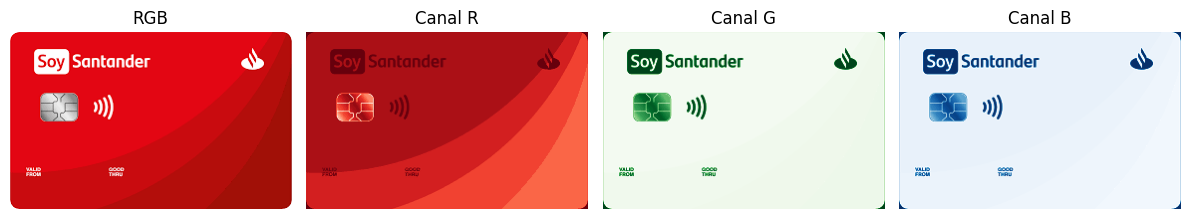

In [ ]:
# Separación de canales R, G, B
if canales == 3:
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(R, cmap="Reds")
    axes[1].set_title("Canal R")
    axes[1].axis("off")

    axes[2].imshow(G, cmap="Greens")
    axes[2].set_title("Canal G")
    axes[2].axis("off")

    axes[3].imshow(B, cmap="Blues")
    axes[3].set_title("Canal B")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

#### Nota: formato BGR en OpenCV

La librería OpenCV (`cv2`) representa las imágenes en formato **BGR** en lugar de RGB. Al cargar una imagen con `cv2.imread`, es necesario convertirla a RGB antes de visualizarla con `matplotlib`.
Este comportamiento se ilustra en el siguiente bloque (solo se ejecuta si OpenCV está disponible).

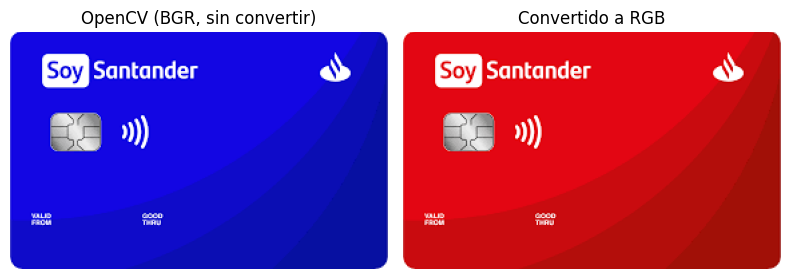

In [ ]:
if OPENCV_AVAILABLE:
    img_bgr = cv2.imread(str(image_path))  # BGR
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_bgr)
    axes[0].set_title("OpenCV (BGR, sin convertir)")
    axes[0].axis("off")

    axes[1].imshow(img_rgb)
    axes[1].set_title("Convertido a RGB")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## 2. Espacios de color: RGB y escala de grises

En muchos algoritmos de visión por computador, resulta útil trabajar con imágenes en **escala de grises**. Para ello se realiza una conversión desde RGB a un único canal de luminancia. `skimage.color.rgb2gray` devuelve una imagen de tipo `float` con valores en el rango `[0, 1]`.

In [ ]:
if img.ndim == 3 and img.shape[2] == 3:
    img_gray = color.rgb2gray(img)
else:
    # Si ya es una imagen de un canal, se asume que está en escala de grises
    img_gray = img

print("Forma imagen gris:", img_gray.shape)
print("Rango de valores gris: [{:.3f}, {:.3f}]".format(img_gray.min(), img_gray.max()))

Forma imagen gris: (178, 283)
Rango de valores gris: [0.156, 1.000]


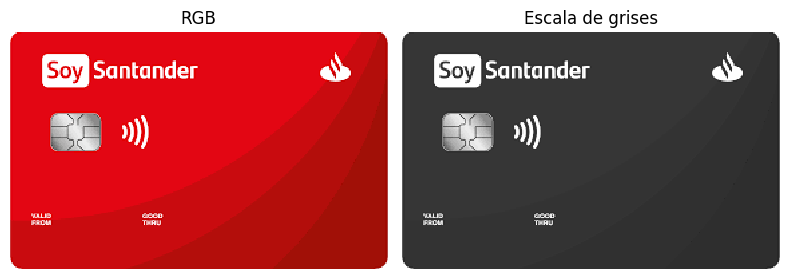

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Imagen RGB
plt.sca(axes[0])             # Seleccionar el eje donde dibujar
io.imshow(img)               # Mostrar usando io.imshow()
axes[0].set_title("RGB")
axes[0].axis("off")

# Imagen en escala de grises
plt.sca(axes[1])
io.imshow(img_gray)          # io.imshow detecta automáticamente que es gris
axes[1].set_title("Escala de grises")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2.1 Análisis detallado de histogramas

Los histogramas permiten comprender la distribución de intensidades (o color) de una imagen.
A continuación se incorpora una función utilitaria para representar histogramas por canal y algunas
métricas que facilitan la interpretación. El estilo de las explicaciones es impersonal.


In [ ]:
def plot_histogram(img, bins=256, ax=None, show_stats=True):
    """
    Representa el histograma de una imagen en escala de grises o en color.

    Parámetros
    ----------
    img : array_like
        Imagen en uint8 (0-255) o float (0-1). Puede ser 2D (gris) o 3D (RGB).
    bins : int
        Número de bins para el histograma (por canal).
    ax : matplotlib.axes.Axes, opcional
        Eje donde dibujar. Si no se proporciona, se crea uno nuevo.
    show_stats : bool
        Si True, imprime estadísticas básicas por canal.
    """
    img_arr = np.asarray(img)
    is_uint8 = img_arr.dtype == np.uint8

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    if img_arr.ndim == 2:
        # Escala de grises
        vals = img_arr.flatten()
        vals_plot = (vals * 255).ravel() if not is_uint8 else vals

        ax.hist(vals_plot, bins=bins, range=(0, 255), color="darkgrey")
        ax.set_title("Histograma (escala de grises)")
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Frecuencia")

        if show_stats:
            print(f"Media: {vals.mean():.4f}, Mediana: {np.median(vals):.4f}, "
                  f"Desviación típica: {vals.std():.4f}")

    elif img_arr.ndim == 3 and img_arr.shape[2] == 3:
        # Color RGB
        factor = 1.0 if is_uint8 else 255.0
        canales = {"R": "red", "G": "green", "B": "blue"}

        for idx, (nombre, col) in enumerate(canales.items()):
            canal = img_arr[:, :, idx].ravel() * factor
            ax.hist(canal, bins=bins, range=(0, 255), color=col, alpha=0.6, label=nombre)

            if show_stats:
                vals_orig = canal / factor
                print(f"Canal {nombre} -> media: {vals_orig.mean():.4f}, "
                      f"mediana: {np.median(vals_orig):.4f}, std: {vals_orig.std():.4f}")

        ax.set_title("Histograma por canal (RGB)")
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Frecuencia")
        ax.legend()

    else:
        raise ValueError("Formato de imagen no soportado (se espera 2D o RGB 3 canales).")

    plt.tight_layout()
    plt.show()

### Interpretación de histogramas

Las conclusiones que se pueden obtener al observar un histograma incluyen, entre otras:

- Presencia de valores cercanos a 0 (píxeles muy oscuros): indica zonas subexpuestas o negros en la imagen.
- Picos alrededor de valores bajos (por ejemplo ~50 en 0-255): la imagen contiene predominio de tonos oscuros o gris oscuro.
- Concentración en extremos (cerca de 0 y/o 255): posible pérdida de detalle por saturación (clipping), baja dinámica.
- Distribución muy estrecha alrededor de un valor: bajo contraste.
- Distribución amplia y bimodal: puede indicar presencia de fondo y objeto con intensidades distintas.

Ejemplos de deducciones concretas aplicables a la imagen actual:

- Si el histograma muestra un gran número de valores en 0, existen píxeles completamente negros.
- Si la mayor parte de los píxeles se concentra alrededor de 50, se concluye que la imagen es predominantemente de tonos oscuros.

Además de la representación visual, conviene calcular métricas resumen (media, mediana, desviación típica, porcentaje de píxeles en rangos) para cuantificar estas observaciones -- la función anterior imprime la media, mediana y desviación típica por canal.


Canal R -> media: 207.8414, mediana: 227.0000, std: 25.4891
Canal G -> media: 22.2022, mediana: 11.0000, std: 49.9762
Canal B -> media: 27.7107, mediana: 19.0000, std: 48.7136


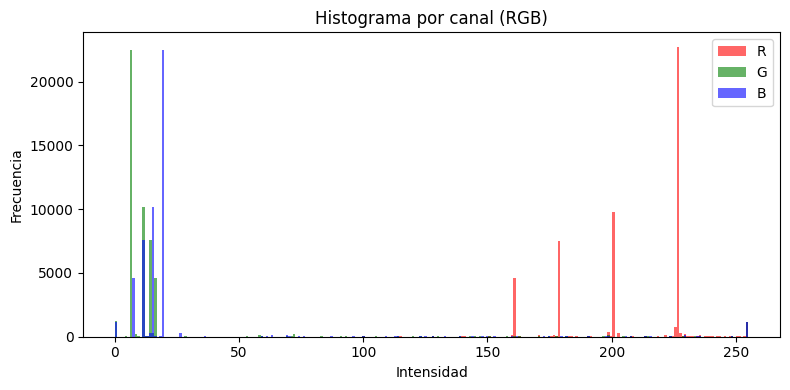

Media: 0.2433, Mediana: 0.2114, Desviación típica: 0.1595


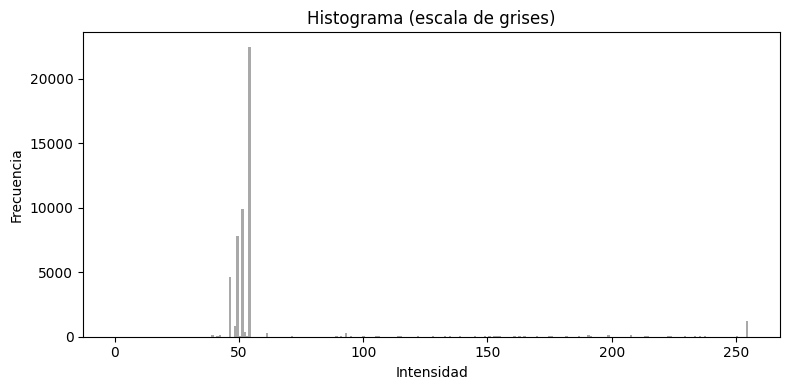

Canal R: % píxeles =0 -> 0.00%, % píxeles =255 -> 2.36%
Canal G: % píxeles =0 -> 2.39%, % píxeles =255 -> 2.36%
Canal B: % píxeles =0 -> 2.25%, % píxeles =255 -> 2.36%


In [ ]:
# Histograma de la imagen original (RGB)
fig, ax = plt.subplots(figsize=(8, 4))
plot_histogram(img, ax=ax)

# Histograma de la versión en escala de grises
fig, ax = plt.subplots(figsize=(8, 4))
plot_histogram(img_gray, ax=ax)

# Métricas adicionales: porcentaje de píxeles muy oscuros y saturados
def pct_pixels_in_range(arr, low, high):
    a = np.asarray(arr)
    if a.dtype != np.uint8:
        a = (a * 255).astype(np.uint8)
    return 100.0 * ((a >= low) & (a <= high)).sum() / a.size

if img.ndim == 3 and img.shape[2] == 3:
    for ch, name in enumerate(["R", "G", "B"]):
        pct0 = pct_pixels_in_range(img[:, :, ch], 0, 0)
        pct255 = pct_pixels_in_range(img[:, :, ch], 255, 255)
        print(f"Canal {name}: % píxeles =0 -> {pct0:.2f}%, % píxeles =255 -> {pct255:.2f}%")
else:
    pct0 = pct_pixels_in_range(img_gray, 0, 0)
    pct255 = pct_pixels_in_range(img_gray, 255, 255)
    print(f"Gris: % píxeles =0 -> {pct0:.2f}%, % píxeles =255 -> {pct255:.2f}%")

### 2.2 Tipos de dato y normalización

El tipo de dato de la imagen influye en cómo se interpretan los valores de los píxeles:

- `uint8`: valores enteros entre 0 y 255 (formato habitual en ficheros de imagen).
- `float32` o `float64`: valores reales en un rango que suele normalizarse a `[0, 1]`.

Muchos modelos de aprendizaje profundo requieren que las imágenes estén **normalizadas** (por ejemplo, en `[0, 1]` o centradas en torno a 0). A continuación se muestra cómo convertir a `float` y normalizar.

Tipo de dato tras conversión: float64
Rango tras conversión: [0.156, 1.000]


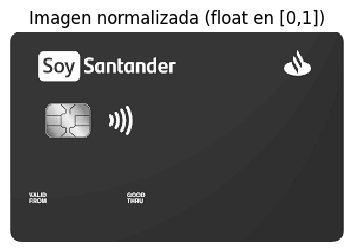

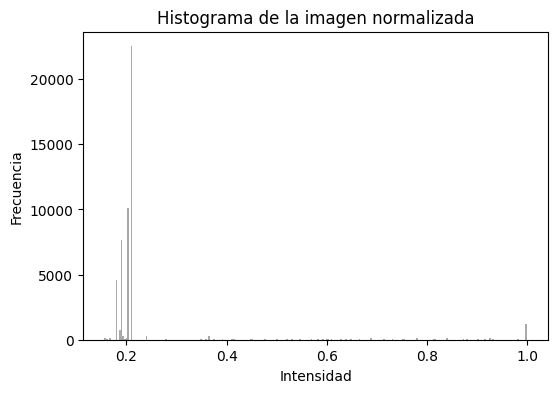

In [ ]:
def to_float01(img):
    """Convierte la imagen a float en el rango [0, 1]."""
    img_float = util.img_as_float(img)
    print("Tipo de dato tras conversión:", img_float.dtype)
    print("Rango tras conversión: [{:.3f}, {:.3f}]".format(img_float.min(), img_float.max()))
    return img_float

# Conversión
img_gray_float = to_float01(img_gray)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray_float, cmap="gray")
axes[0].set_title("Imagen normalizada (float [0,1])")
axes[0].axis("off")

axes[1].hist(img_gray_float.ravel(), bins=256, color="darkgray")
axes[1].set_title("Histograma de la imagen normalizada")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 3. Redimensionado y recorte

En visión por computador es habitual adaptar todas las imágenes a un **tamaño fijo** para poder procesarlas en lotes (por ejemplo, en una red neuronal). `skimage.transform.resize` permite redimensionar una imagen a un tamaño concreto, realizando un reescalado continuo.

También resulta útil recortar regiones de interés (ROI) mediante indexación.

Forma original: (178, 283, 3)
Forma redimensionada: (224, 224, 3)


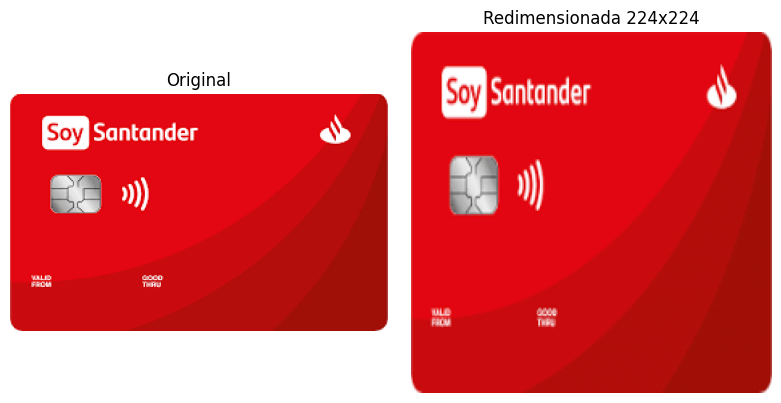

In [ ]:
target_shape = (224, 224)  # alto, ancho

img_resized = transform.resize(img, target_shape, anti_aliasing=True)
print("Forma original:", img.shape)
print("Forma redimensionada:", img_resized.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_resized)
axes[1].set_title("Redimensionada 224x224")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Forma recorte: (89, 89, 3)


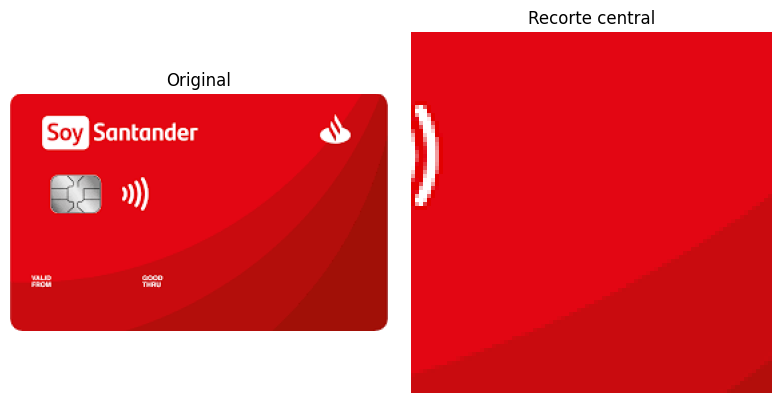

In [ ]:
# Recorte simple: región central de la imagen
h, w = img.shape[:2]
crop_size = min(h, w) // 2

start_row = h // 2 - crop_size // 2
end_row = start_row + crop_size
start_col = w // 2 - crop_size // 2
end_col = start_col + crop_size

img_cropped = img[start_row:end_row, start_col:end_col]
print("Forma recorte:", img_cropped.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_cropped)
axes[1].set_title("Recorte central")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4. Transformaciones geométricas simples

Como parte del preprocesamiento o de la **aumentación de datos**, se suelen aplicar transformaciones geométricas simples como volteos y rotaciones. Estas operaciones ayudan a hacer los modelos más robustos a variaciones de orientación y simetría.

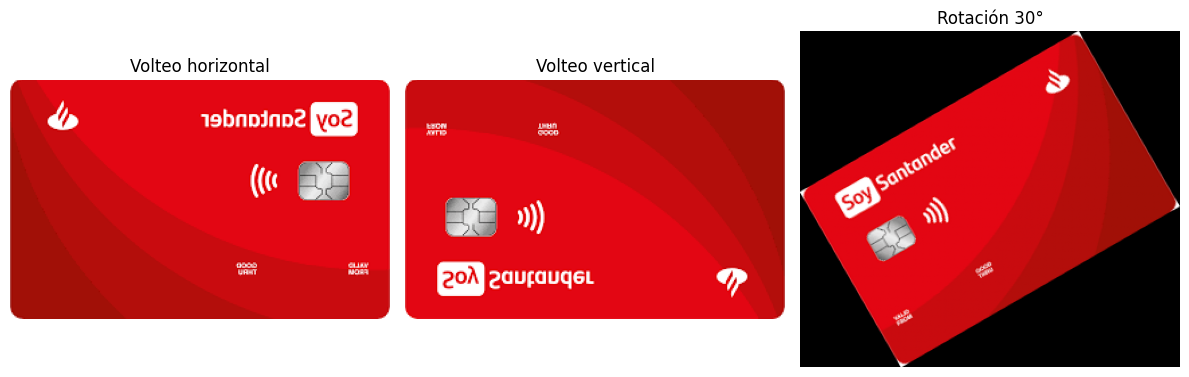

In [ ]:
img_fliplr = np.fliplr(img)
img_flipud = np.flipud(img)
img_rotated = transform.rotate(img, angle=30, resize=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_fliplr)
axes[0].set_title("Volteo horizontal")
axes[0].axis("off")

axes[1].imshow(img_flipud)
axes[1].set_title("Volteo vertical")
axes[1].axis("off")

axes[2].imshow(img_rotated)
axes[2].set_title("Rotación 30°")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5. Histogramas y mejora de contraste

El **histograma** de una imagen describe la distribución de intensidades. A partir de él se pueden aplicar técnicas de mejora de contraste como la **ecualización de histograma** o la ecualización adaptativa (CLAHE).

Se parte de una imagen en escala de grises normalizada y se aplican distintos métodos de realce.

Tipo de dato tras conversión: float64
Rango tras conversión: [0.156, 1.000]


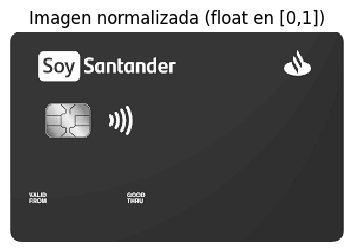

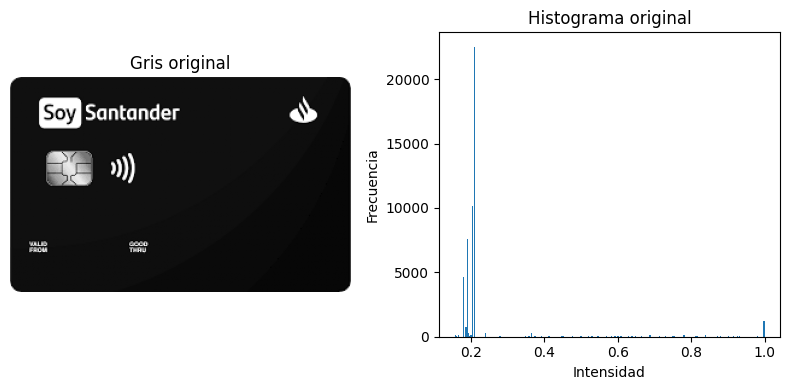

In [ ]:
# img_gray_float ya fue calculada en la sección 2.2

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_gray_float, cmap="gray")
axes[0].set_title("Gris original")
axes[0].axis("off")

axes[1].hist(img_gray_float.ravel(), bins=256)
axes[1].set_title("Histograma original")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

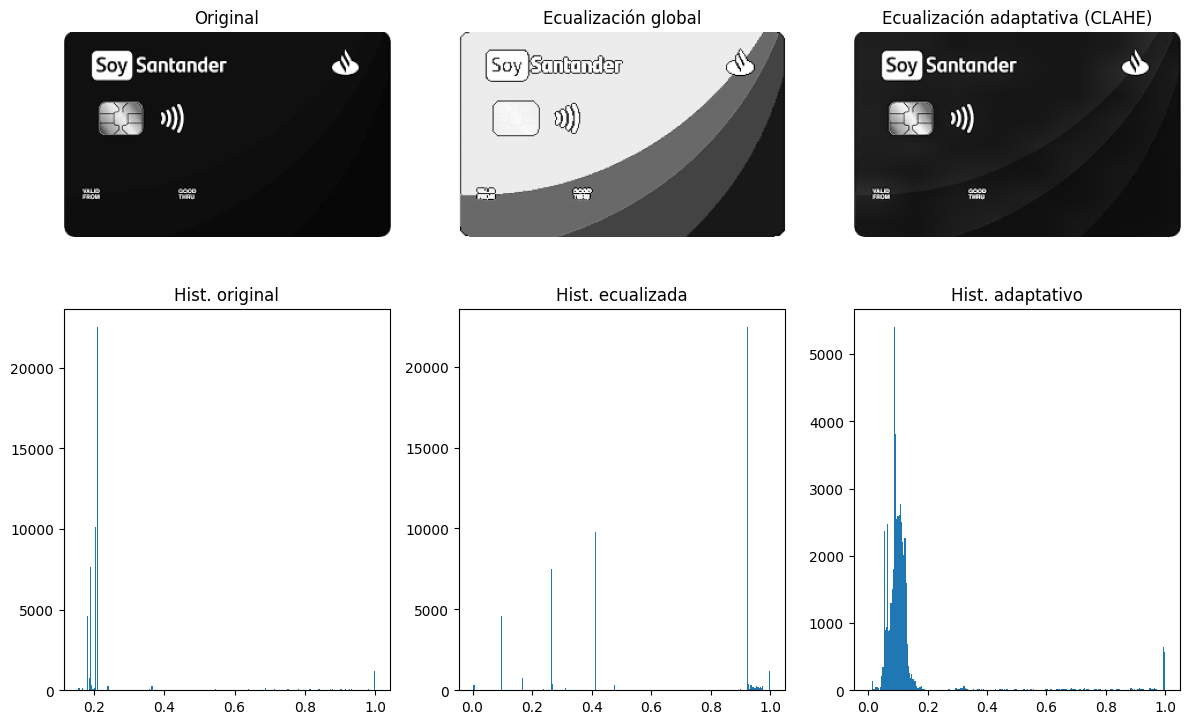

In [ ]:
img_eq = exposure.equalize_hist(img_gray_float)
img_adapteq = exposure.equalize_adapthist(img_gray_float, clip_limit=0.03)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(img_gray_float, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")
axes[1, 0].hist(img_gray_float.ravel(), bins=256)
axes[1, 0].set_title("Hist. original")

axes[0, 1].imshow(img_eq, cmap="gray")
axes[0, 1].set_title("Ecualización global")
axes[0, 1].axis("off")
axes[1, 1].hist(img_eq.ravel(), bins=256)
axes[1, 1].set_title("Hist. ecualizada")

axes[0, 2].imshow(img_adapteq, cmap="gray")
axes[0, 2].set_title("Ecualización adaptativa (CLAHE)")
axes[0, 2].axis("off")
axes[1, 2].hist(img_adapteq.ravel(), bins=256)
axes[1, 2].set_title("Hist. adaptativo")

plt.tight_layout()
plt.show()

### Ejemplo práctico: mejora de imágenes oscuras mediante ecualización adaptativa

En esta sección se ilustra cómo la ecualización del histograma puede mejorar significativamente la visibilidad en imágenes con poca iluminación. Se parte de una imagen oscura y se analiza su histograma antes y después de aplicar ecualización adaptativa (CLAHE).


Forma de la imagen cargada: (400, 640, 3)


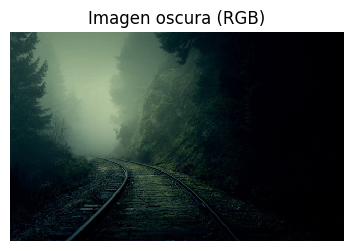

In [ ]:
# Carga de una imagen oscura
ruta_dark = "img/dark.jpg"

# Lectura con OpenCV (BGR -> RGB) o con skimage
if OPENCV_AVAILABLE:
    img_dark_bgr = cv2.imread(ruta_dark)
    img_dark_rgb = cv2.cvtColor(img_dark_bgr, cv2.COLOR_BGR2RGB)
else:
    img_dark_rgb = io.imread(ruta_dark)

print("Forma de la imagen cargada:", img_dark_rgb.shape)

# Visualización de la imagen original
plt.figure(figsize=(4, 4))
io.imshow(img_dark_rgb)
plt.title("Imagen oscura (RGB)")
plt.axis("off")
plt.show()

### Conversión a escala de grises y análisis del histograma

Se convierte la imagen a escala de grises para analizar su distribución tonal. En imágenes oscuras, el histograma suele concentrarse en valores bajos.


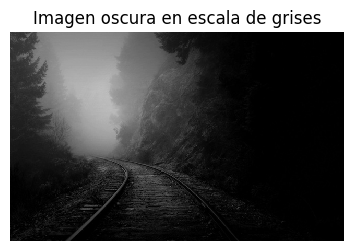

Media: 0.1573, Mediana: 0.0519, Desviación típica: 0.2064


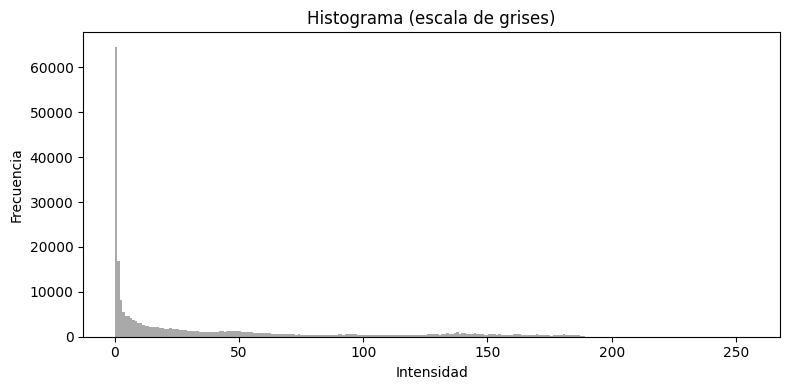

In [ ]:
img_dark_gray = color.rgb2gray(img_dark_rgb)

# Visualización en escala de grises
plt.figure(figsize=(4, 4))
io.imshow(img_dark_gray, cmap="gray")
plt.title("Imagen oscura en escala de grises")
plt.axis("off")
plt.show()

# Histograma de la imagen oscura
plot_histogram(img_dark_gray)


### Aplicación de ecualización adaptativa (CLAHE)

La ecualización adaptativa de histograma redistribuye los niveles de intensidad dentro de pequeñas regiones locales.  
Esto permite revelar estructuras que no son perceptibles en la imagen original debido a su baja iluminación.


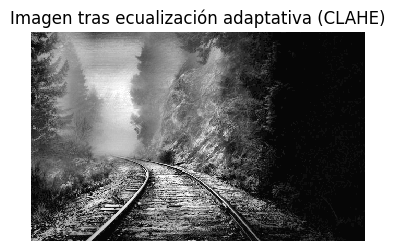

Media: 0.3163, Mediana: 0.2847, Desviación típica: 0.2636


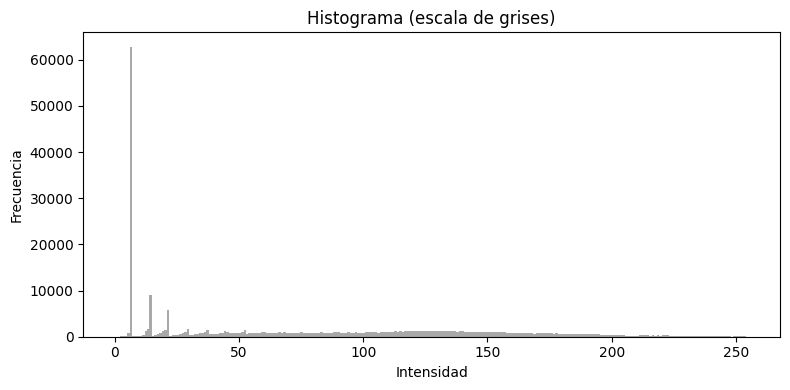

In [ ]:
img_dark_gray_equalized = exposure.equalize_adapthist(img_dark_gray, clip_limit=0.03)

# Visualización de la imagen ecualizada
plt.figure(figsize=(4, 4))
io.imshow(img_dark_gray_equalized, cmap="gray")
plt.title("Imagen tras ecualización adaptativa (CLAHE)")
plt.axis("off")
plt.show()

# Histograma tras ecualización
plot_histogram(img_dark_gray_equalized)


### Comparación lado a lado

A continuación se comparan directamente la imagen original y la ecualizada para observar el incremento de contraste y detalle.


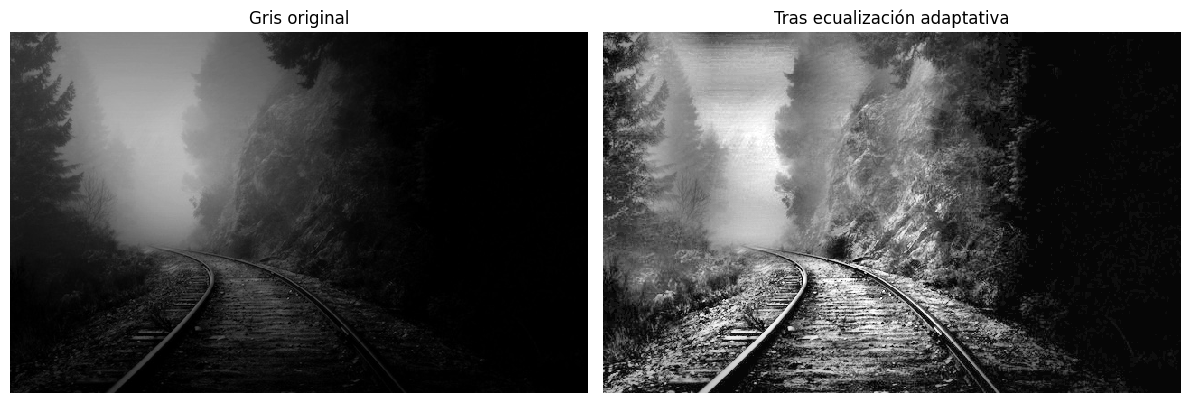

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

plt.sca(ax[0])
io.imshow(img_dark_gray, cmap="gray")
ax[0].set_title("Gris original")
ax[0].axis("off")

plt.sca(ax[1])
io.imshow(img_dark_gray_equalized, cmap="gray")
ax[1].set_title("Tras ecualización adaptativa")
ax[1].axis("off")

plt.tight_layout()
plt.show()


### Interpretación

El objetivo de la ecualización es redistribuir los niveles de intensidad para resaltar información que, en la imagen original, puede pasar desapercibida.  
En este ejemplo:

- La imagen original presenta la mayor parte de sus intensidades concentradas en valores muy bajos.
- Tras aplicar ecualización adaptativa, se amplía el rango dinámico local.
- Se revelan detalles y formas que no eran apreciables en la versión oscura.

Este proceso es especialmente útil en tareas de visión donde la iluminación deficiente puede ocultar características relevantes.


## 6. Extracción de bordes sencilla

Los bordes señalan cambios bruscos de intensidad y son una pista importante sobre la **estructura de los objetos**. Un primer paso habitual consiste en calcular un mapa de bordes utilizando operadores como Sobel.

En este ejemplo se aplica el filtro de Sobel sobre la imagen en escala de grises.

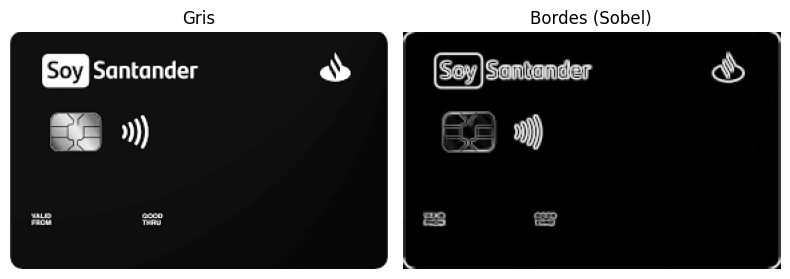

In [ ]:
edges = filters.sobel(img_gray_float)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_gray_float, cmap="gray")
axes[0].set_title("Gris")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Bordes (Sobel)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Pipeline de preprocesamiento reutilizable

En proyectos reales resulta conveniente encapsular la lógica de preprocesamiento en una **función reutilizable**. De este modo, todas las imágenes se tratan de manera coherente antes de ser utilizadas para entrenamiento o evaluación de modelos.

A continuación se define una función de ejemplo que:

1. Carga una imagen desde disco.
2. La convierte a RGB (si se utiliza OpenCV).
3. Opcionalmente la convierte a escala de grises.
4. La redimensiona a un tamaño objetivo.
5. La normaliza al rango `[0, 1]`.

El resultado es un array listo para ser utilizado en un modelo de aprendizaje automático.

Forma imagen preprocesada: (224, 224)
Rango de valores: [0.158, 1.000]


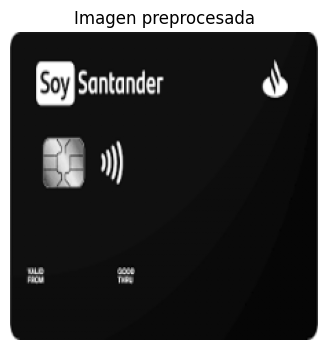

In [ ]:
def load_and_preprocess(path, target_shape=(224, 224), to_gray=False, use_opencv=False):
    """Carga y preprocesa una imagen.

    Parámetros
    ----------
    path : str o Path
        Ruta del fichero de imagen.
    target_shape : (int, int)
        Tamaño objetivo (alto, ancho) para redimensionar.
    to_gray : bool
        Si es True, se convierte a escala de grises.
    use_opencv : bool
        Si es True y OpenCV está disponible, se utiliza cv2.imread.
    """

    if use_opencv and OPENCV_AVAILABLE:
        img = cv2.imread(str(path))  # BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = io.imread(path)

    # Conversión a escala de grises si se solicita
    if to_gray:
        if img.ndim == 3 and img.shape[2] == 3:
            img = color.rgb2gray(img)
        # Si ya es 2D se asume que está en gris

    # Redimensionado
    img_resized = transform.resize(img, target_shape, anti_aliasing=True)

    # Normalización a [0, 1]
    img_preprocessed = util.img_as_float(img_resized)

    return img_preprocessed


# Ejemplo de uso (ajustar la ruta de la imagen)
preprocessed = load_and_preprocess(image_path, target_shape=(224, 224), to_gray=True)
print("Forma imagen preprocesada:", preprocessed.shape)
print("Rango de valores: [{:.3f}, {:.3f}]".format(preprocessed.min(), preprocessed.max()))

plt.imshow(preprocessed, cmap="gray")
plt.title("Imagen preprocesada")
plt.axis("off")
plt.show()